<a href="https://colab.research.google.com/github/kamalatul123/visi-komputer/blob/main/UTS_Visi_23423049.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

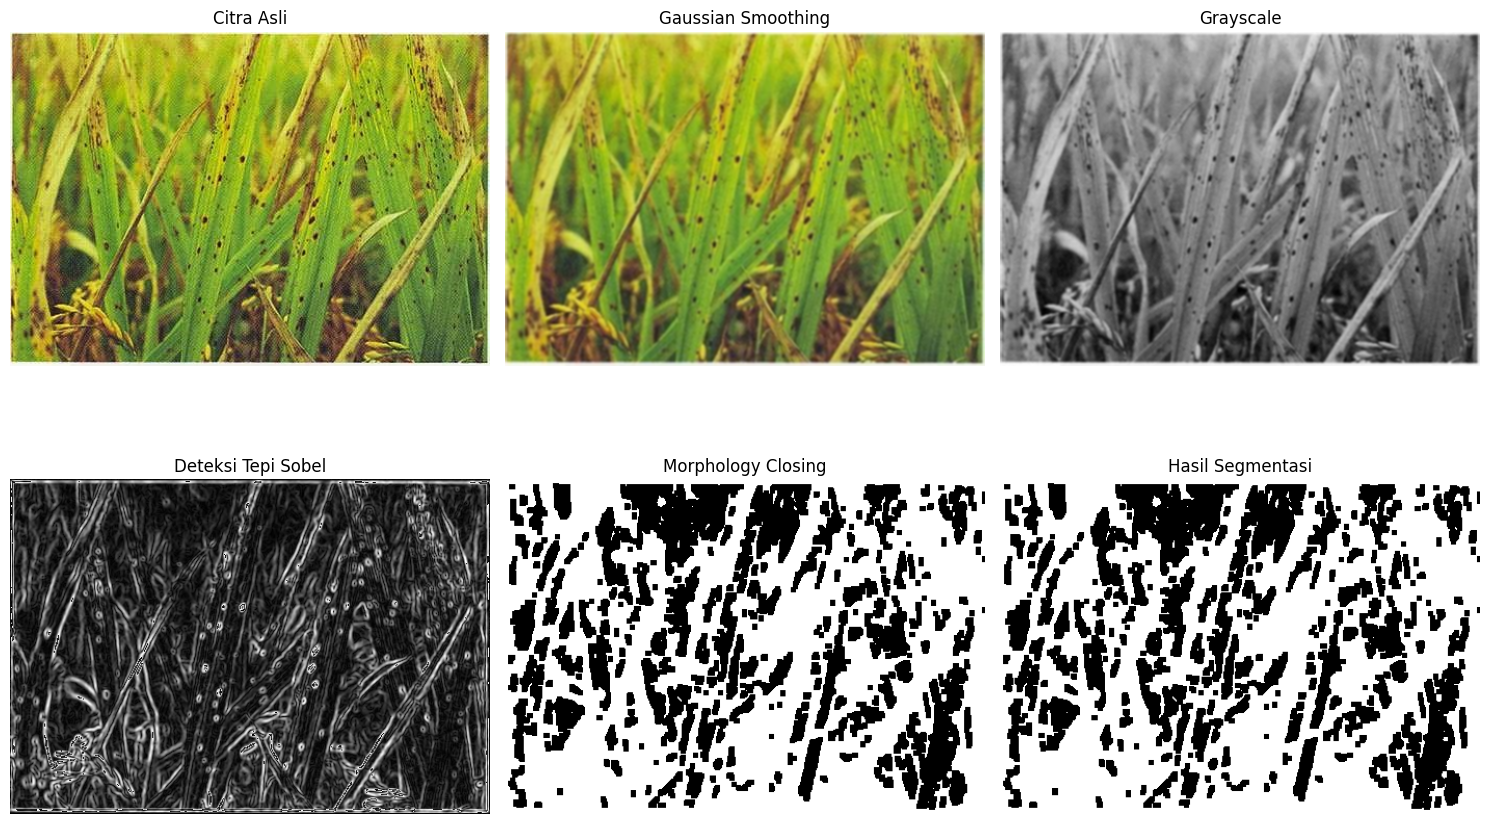

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# BACA GAMBAR
# =========================
img = cv2.imread('padi1.jpg')

# cek gambar
if img is None:
    print("Gambar tidak ditemukan")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# GAUSSIAN SMOOTHING
# =========================
gaussian = cv2.GaussianBlur(img_rgb, (5,5), 0)

# =========================
# GRAYSCALE
# =========================
gray = cv2.cvtColor(gaussian, cv2.COLOR_RGB2GRAY)

# =========================
# DETEKSI TEPI SOBEL
# =========================
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = np.sqrt(sobelx**2 + sobely**2)
sobel = np.uint8(sobel)

# =========================
# THRESHOLD AWAL
# =========================
_, binary = cv2.threshold(sobel, 50, 255, cv2.THRESH_BINARY)

# =========================
# MORFOLOGI CLOSING
# =========================
kernel = np.ones((5,5), np.uint8)

closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

# =========================
# THRESHOLDING AKHIR
# =========================
_, final = cv2.threshold(
    closing,
    127,
    255,
    cv2.THRESH_BINARY
)

# =========================
# TAMPILKAN HASIL
# =========================
titles = [
    'Citra Asli',
    'Gaussian Smoothing',
    'Grayscale',
    'Deteksi Tepi Sobel',
    'Morphology Closing',
    'Hasil Segmentasi'
]

images = [
    img_rgb,
    gaussian,
    gray,
    sobel,
    closing,
    final
]

plt.figure(figsize=(15,10))

for i in range(len(images)):
    plt.subplot(2,3,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()